In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, "data", "blinkit_dataset.csv")
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(13000, 25)


,product_id,product_name,category,brand,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,...,is_organic,packaging_type,weight_g,shelf_life_days,reorder_level,demand_index,date_added,expiry_date,offer_type,delivery_status
0,1,Tata Organic Grocery 300,Grocery,Tata,199.78,25,149.84,4.5,146,37,...,True,Can,750,212,15,73,2023-11-27,2024-06-26,NaN,On-Time
1,2,Mother Dairy Lite Dairy 275,Dairy,Mother Dairy,44.32,30,31.02,4.0,264,36,...,False,Jar,1000,17,24,25,2024-08-07,2024-08-24,NaN,Delayed
2,3,P&G Classic Personal 439,Personal Care,P&G,501.13,0,501.13,3.7,69,17,...,True,Jar,1000,1463,25,100,2024-03-03,2028-03-05,FreeDelivery,On-Time
3,4,Dettol Fresh Household 771,Household,Dettol,627.17,0,627.17,3.9,103,23,...,True,Bottle,200,1143,18,15,2024-08-07,2027-09-24,NaN,On-Time
4,5,Minute Maid Daily Beverages 264,Beverages,Minute Maid,101.69,15,86.44,4.3,422,10,...,True,Can,300,363,30,6,2024-07-04,2025-07-02,NaN,On-Time


## EDA

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         13000 non-null  int64  
 1   product_name       13000 non-null  object 
 2   category           13000 non-null  object 
 3   brand              13000 non-null  object 
 4   price              13000 non-null  float64
 5   discount_pct       13000 non-null  int64  
 6   final_price        13000 non-null  float64
 7   rating             13000 non-null  float64
 8   num_reviews        13000 non-null  int64  
 9   delivery_time_min  13000 non-null  int64  
 10  city               13000 non-null  object 
 11  seller             13000 non-null  object 
 12  stock              13000 non-null  int64  
 13  sold_quantity      13000 non-null  int64  
 14  profit_margin_pct  13000 non-null  float64
 15  is_organic         13000 non-null  bool   
 16  packaging_type     130

In [3]:
df.describe()

,product_id,price,discount_pct,final_price,rating,num_reviews,delivery_time_min,stock,sold_quantity,profit_margin_pct,weight_g,shelf_life_days,reorder_level,demand_index
count,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000
mean,6500.500000,267.303356,9.959231,240.735212,4.196931,255.000308,27.558769,110.140538,162.400077,22.652708,536.130769,397.555385,21.627769,43.380462
std,3752.921085,199.665148,8.575017,182.405552,0.475863,152.933513,7.139059,19.589137,132.742425,10.088389,406.997451,483.540218,3.928429,27.076935
min,1.000000,10.180000,0.000000,8.140000,2.500000,1.000000,10.000000,52.000000,0.000000,5.000000,100.000000,2.000000,10.000000,0.000000
25%,3250.750000,122.972500,0.000000,108.790000,3.900000,138.000000,23.000000,95.000000,54.000000,13.900000,250.000000,13.000000,19.000000,22.000000
50%,6500.500000,220.240000,10.000000,197.185000,4.200000,219.000000,27.000000,110.000000,120.000000,22.900000,400.000000,231.000000,22.000000,38.000000
75%,9750.250000,350.500000,15.000000,316.882500,4.500000,355.000000,32.000000,125.000000,253.000000,31.400000,750.000000,564.000000,25.000000,63.000000
max,13000.000000,999.930000,30.000000,998.920000,5.000000,1050.000000,56.000000,169.000000,720.000000,40.000000,2000.000000,1825.000000,33.000000,100.000000


In [4]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
brand,0
price,0
discount_pct,0
final_price,0
rating,0
num_reviews,0
delivery_time_min,0


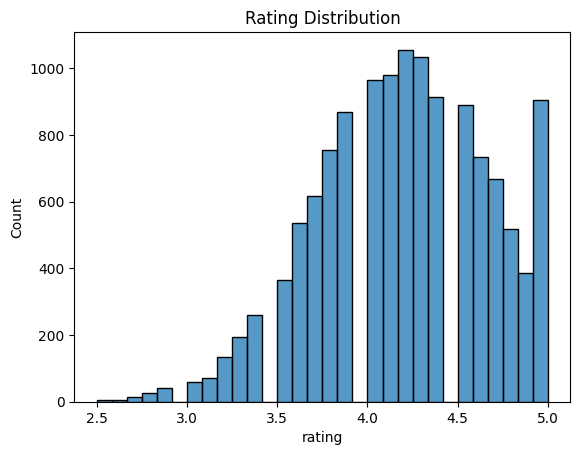

Class split at 3.8:
rating
True     10677
False     2323
Name: count, dtype: int64


In [2]:
sns.histplot(df["rating"], bins=30)
plt.title("Rating Distribution")
plt.show()
print("Class split at 3.8:")
print((df["rating"] >= 3.8).value_counts())

## Feature Engineering

In [3]:
df["offer_type"] = df["offer_type"].fillna("No Offer")

df["date_added"]  = pd.to_datetime(df["date_added"])
df["expiry_date"] = pd.to_datetime(df["expiry_date"])
REFERENCE_DATE = pd.Timestamp("2023-01-01")

df["days_to_expiry"]   = (df["expiry_date"] - df["date_added"]).dt.days
df["days_since_added"] = (df["date_added"] - REFERENCE_DATE).dt.days
df["month_added"]      = df["date_added"].dt.month

In [4]:
df["sell_through_rate"]      = df["sold_quantity"] / (df["sold_quantity"] + df["stock"] + 1)
df["stock_pressure"]         = df["stock"] / (df["reorder_level"] + 1)
df["revenue_proxy"]          = df["final_price"] * df["sold_quantity"]
df["is_delayed"]             = (df["delivery_status"] == "Delayed").astype(int)
df["demand_x_reviews"]       = df["demand_index"] * df["num_reviews"]
df["popularity_score"]       = df["demand_index"] * df["sell_through_rate"]
df["delivery_score"]         = (1 - df["is_delayed"]) / (df["delivery_time_min"] + 1) * 100
df["value_score"]            = df["sold_quantity"] / (df["final_price"] + 1)
df["margin_efficiency"]      = df["profit_margin_pct"] * df["sell_through_rate"] / 100
df["discount_effectiveness"] = (df["price"] - df["final_price"]) * df["sell_through_rate"]
df["review_density"]         = df["num_reviews"] / (df["days_since_added"] + 1) * 100
df["inventory_health"]       = df["sell_through_rate"] / (df["stock_pressure"] + 0.01)
df["discount_amount"]        = df["price"] - df["final_price"]
df["price_per_gram"]         = df["final_price"] / (df["weight_g"] + 1)
df["freshness_score"]        = df["days_to_expiry"] / (df["shelf_life_days"] + 1)

In [5]:
from sklearn.preprocessing import LabelEncoder

CAT_COLS = ["category", "brand", "city", "seller", "packaging_type", "offer_type"]
label_encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    label_encoders[col] = le

df["is_organic_enc"] = df["is_organic"].astype(int)

## Feature Selection + Train-Test Split

In [6]:
FEAT_COLS = [
    "price", "final_price", "discount_pct", "profit_margin_pct", "weight_g", "shelf_life_days",
    "num_reviews", "delivery_time_min", "stock", "sold_quantity", "reorder_level", "demand_index",
    "days_to_expiry", "days_since_added", "month_added",
    "sell_through_rate", "stock_pressure", "revenue_proxy", "is_delayed",
    "demand_x_reviews", "popularity_score", "delivery_score", "value_score",
    "margin_efficiency", "discount_effectiveness", "review_density", "freshness_score",
    "inventory_health", "discount_amount", "price_per_gram",
    "category_enc", "brand_enc", "city_enc", "seller_enc", "packaging_type_enc",
    "offer_type_enc", "is_organic_enc",
]

X = df[FEAT_COLS]
Y = (df["rating"] >= 3.8).astype(int)

print("Feature count:", len(FEAT_COLS))
print("Class distribution:")
print(Y.value_counts())

Feature count: 37
Class distribution:
rating
1    10677
0     2323
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (10400, 37) | Test: (2600, 37)


## Linear Regression Baseline

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

Y_reg = df["rating"]
X_train_r, X_test_r, Y_train_r, Y_test_r = train_test_split(
    X, Y_reg, test_size=0.2, random_state=42
)
X_train_r_s = scaler.transform(X_train_r)
X_test_r_s  = scaler.transform(X_test_r)

lr = LinearRegression()
lr.fit(X_train_r_s, Y_train_r)
Y_pred_reg = lr.predict(X_test_r_s)

print("RMSE:", round(np.sqrt(mean_squared_error(Y_test_r, Y_pred_reg)), 4))
print("MAE :", round(mean_absolute_error(Y_test_r, Y_pred_reg), 4))

RMSE: 0.4352
MAE : 0.3518


## Classification Models

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = [
    ("Logistic Regression", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)),
    ("Random Forest",       RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
    ("LightGBM",            LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1)),
]

for name, model in models:
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test_scaled)
    print(f"\n{name}")
    print("Accuracy :", round(accuracy_score(Y_test, Y_pred), 4))
    print("Precision:", round(precision_score(Y_test, Y_pred), 4))
    print("Recall   :", round(recall_score(Y_test, Y_pred), 4))
    print("F1       :", round(f1_score(Y_test, Y_pred), 4))
    print("Macro F1 :", round(f1_score(Y_test, Y_pred, average="macro"), 4))


Logistic Regression
Accuracy : 0.6596
Precision: 0.8961
Recall   : 0.6623
F1       : 0.7616
Macro F1 : 0.5832

Random Forest
Accuracy : 0.7927
Precision: 0.8364
Recall   : 0.9293
F1       : 0.8804
Macro F1 : 0.5513

LightGBM
Accuracy : 0.7215
Precision: 0.8715
Recall   : 0.7752
F1       : 0.8205
Macro F1 : 0.5998


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [11]:
from lightgbm import LGBMClassifier

best_lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=50,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
best_lgbm.fit(X_train_scaled, Y_train)
print("Post-launch model trained!")
from sklearn.metrics import f1_score
Y_pred = best_lgbm.predict(X_test_scaled)
print("Best Macro F1:", round(f1_score(Y_test, Y_pred, average='macro'), 4))


Post-launch model trained!
Best Macro F1: 0.5888


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":  [100, 200, 300],
    "max_depth":     [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves":    [20, 31, 50],
}

lgbm = LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1)

search_grid = GridSearchCV(
    lgbm, param_grid, cv=5, scoring="f1_macro", n_jobs=-1
)
search_grid.fit(X_train_scaled, Y_train)

print("Best params:", search_grid.best_params_)
print("Best Macro F1:", round(search_grid.best_score_, 4))

/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does n

KeyboardInterrupt: 

In [14]:
Y_pred_best = search_grid.best_estimator_.predict(X_test_scaled)

print("Tuned LightGBM on Test Set:")
print("Accuracy :", round(accuracy_score(Y_test, Y_pred_best), 4))
print("Precision:", round(precision_score(Y_test, Y_pred_best), 4))
print("Recall   :", round(recall_score(Y_test, Y_pred_best), 4))
print("F1       :", round(f1_score(Y_test, Y_pred_best), 4))
print("Macro F1 :", round(f1_score(Y_test, Y_pred_best, average="macro"), 4))

Tuned LightGBM on Test Set:
Accuracy : 0.7108
Precision: 0.8704
Recall   : 0.7611
F1       : 0.8121
Macro F1 : 0.5922


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [15]:
param_grid_lr = {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "liblinear"]}
lr_tune = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
search_lr = GridSearchCV(lr_tune, param_grid_lr, cv=5, scoring="f1_macro", n_jobs=-1)
search_lr.fit(X_train_scaled, Y_train)
Y_pred_lr = search_lr.best_estimator_.predict(X_test_scaled)
print("Best params:", search_lr.best_params_)
print("Accuracy :", round(accuracy_score(Y_test, Y_pred_lr), 4))
print("Precision:", round(precision_score(Y_test, Y_pred_lr), 4))
print("Recall   :", round(recall_score(Y_test, Y_pred_lr), 4))
print("F1       :", round(f1_score(Y_test, Y_pred_lr), 4))
print("Macro F1 :", round(f1_score(Y_test, Y_pred_lr, average="macro"), 4))

Best params: {'C': 10, 'solver': 'lbfgs'}
Accuracy : 0.6592
Precision: 0.896
Recall   : 0.6618
F1       : 0.7613
Macro F1 : 0.5829


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


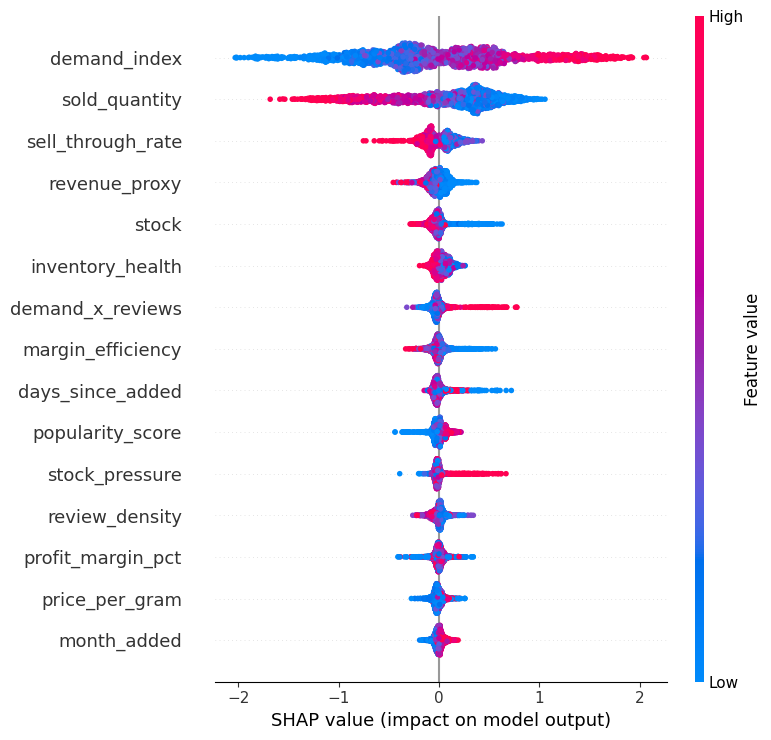

In [17]:
import shap

output_dir = "/content/deck/ml"
os.makedirs(output_dir, exist_ok=True)

explainer   = shap.TreeExplainer(search_grid.best_estimator_)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEAT_COLS, max_display=15, show=False)
plt.savefig("/content/deck/ml/shap_beeswarm_post.png", dpi=150, bbox_inches="tight")
plt.show()

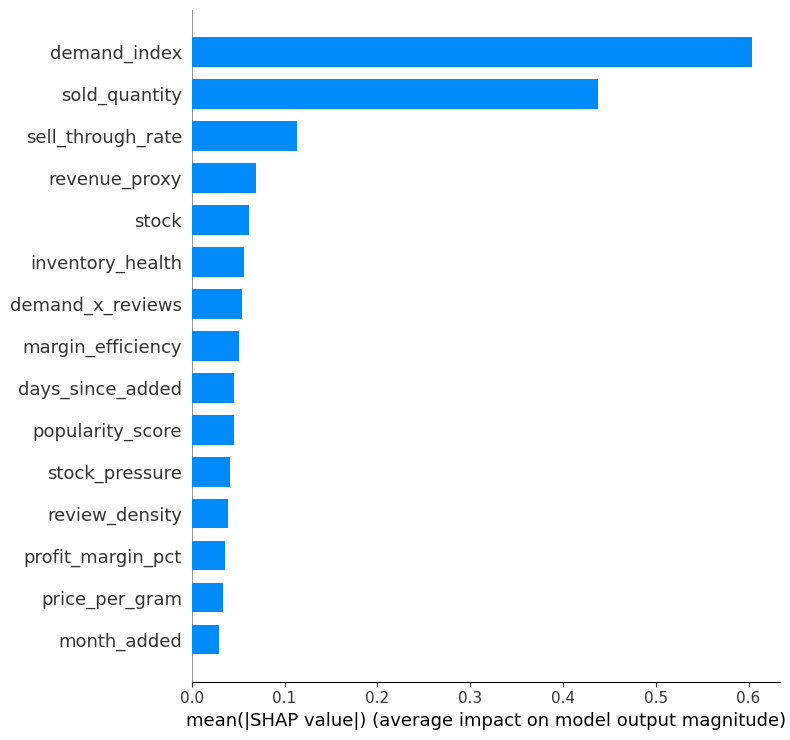

In [18]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEAT_COLS,
                  plot_type="bar", max_display=15, show=False)
plt.savefig("/content/deck/ml/shap_bar_post.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid_rf = {"n_estimators": [100, 200], "max_depth": [6, 10, None], "min_samples_split": [2, 5]}
rf_tune = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
search_rf = GridSearchCV(rf_tune, param_grid_rf, cv=5, scoring="f1_macro", n_jobs=-1)
search_rf.fit(X_train_scaled, Y_train)
Y_pred_rf = search_rf.best_estimator_.predict(X_test_scaled)

print("Best params:", search_rf.best_params_)
print("Accuracy :", round(accuracy_score(Y_test, Y_pred_rf), 4))
print("Precision:", round(precision_score(Y_test, Y_pred_rf), 4))
print("Recall   :", round(recall_score(Y_test, Y_pred_rf), 4))
print("F1       :", round(f1_score(Y_test, Y_pred_rf), 4))
print("Macro F1 :", round(f1_score(Y_test, Y_pred_rf, average="macro"), 4))


Best params: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy : 0.715
Precision: 0.8593
Recall   : 0.7808
F1       : 0.8182
Macro F1 : 0.5797


         Model  Accuracy  Precision  Recall     F1  Macro F1
      Tuned LR    0.6592     0.8960  0.6618 0.7613    0.5829
      Tuned RF    0.7150     0.8593  0.7808 0.8182    0.5797
Tuned LightGBM    0.7108     0.8704  0.7611 0.8121    0.5922


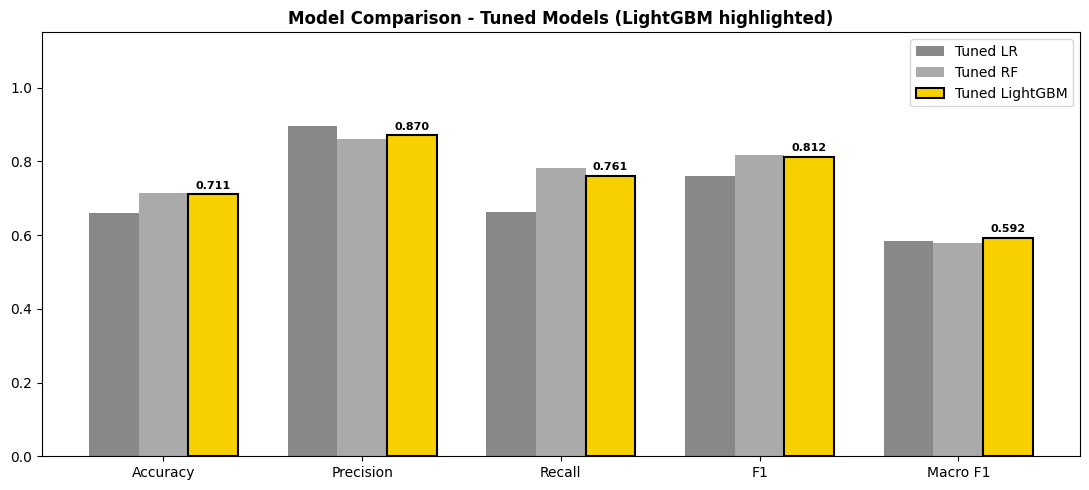

In [21]:
import numpy as np

results = pd.DataFrame({
    "Model": ["Tuned LR", "Tuned RF", "Tuned LightGBM"],
    "Accuracy":  [round(accuracy_score(Y_test, Y_pred_lr), 4),
                  round(accuracy_score(Y_test, Y_pred_rf), 4),
                  round(accuracy_score(Y_test, Y_pred_best), 4)],
    "Precision": [round(precision_score(Y_test, Y_pred_lr), 4),
                  round(precision_score(Y_test, Y_pred_rf), 4),
                  round(precision_score(Y_test, Y_pred_best), 4)],
    "Recall":    [round(recall_score(Y_test, Y_pred_lr), 4),
                  round(recall_score(Y_test, Y_pred_rf), 4),
                  round(recall_score(Y_test, Y_pred_best), 4)],
    "F1":        [round(f1_score(Y_test, Y_pred_lr), 4),
                  round(f1_score(Y_test, Y_pred_rf), 4),
                  round(f1_score(Y_test, Y_pred_best), 4)],
    "Macro F1":  [round(f1_score(Y_test, Y_pred_lr, average="macro"), 4),
                  round(f1_score(Y_test, Y_pred_rf, average="macro"), 4),
                  round(f1_score(Y_test, Y_pred_best, average="macro"), 4)],
})
print(results.to_string(index=False))

metrics = ["Accuracy", "Precision", "Recall", "F1", "Macro F1"]
x = np.arange(len(metrics))
width = 0.25
colors = ["#888888", "#AAAAAA", "#F8D000"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics], width,
                  label=row["Model"], color=colors[i],
                  edgecolor="black" if row["Model"] == "Tuned LightGBM" else "none",
                  linewidth=1.5)
    if row["Model"] == "Tuned LightGBM":
        for bar in bars:
            ax.annotate(f'{bar.get_height():.3f}',
                        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        xytext=(0, 4), textcoords="offset points",
                        ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_title("Model Comparison - Tuned Models (LightGBM highlighted)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("/content/deck/ml/model_comparison_post.png", dpi=150, bbox_inches="tight")
plt.show()

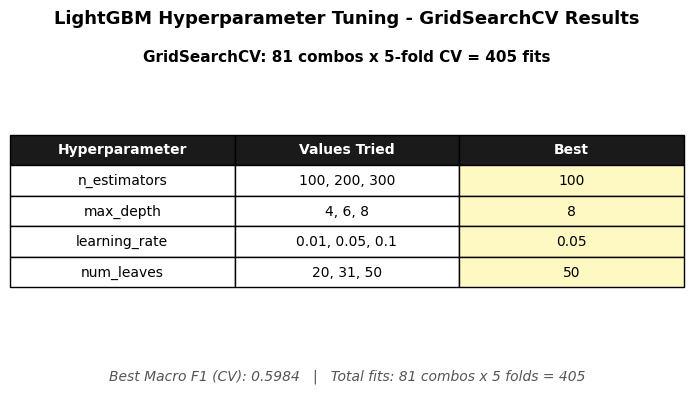

In [22]:
import os
fig, ax = plt.subplots(figsize=(7, 4))
ax.axis("off")
grid_data = [
    ["Hyperparameter", "Values Tried", "Best"],
    ["n_estimators",   "100, 200, 300", str(search_grid.best_params_["n_estimators"])],
    ["max_depth",      "4, 6, 8",       str(search_grid.best_params_["max_depth"])],
    ["learning_rate",  "0.01, 0.05, 0.1", str(search_grid.best_params_["learning_rate"])],
    ["num_leaves",     "20, 31, 50",    str(search_grid.best_params_["num_leaves"])],
]
table = ax.table(cellText=grid_data[1:], colLabels=grid_data[0], cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#1A1A1A")
        cell.set_text_props(color="white", fontweight="bold")
    elif col == 2 and row > 0:
        cell.set_facecolor("#FEF9C3")
ax.set_title("GridSearchCV: 81 combos x 5-fold CV = 405 fits", fontweight="bold", fontsize=11)
ax.text(0.5, -0.1,
        f"Best Macro F1 (CV): {search_grid.best_score_:.4f}   |   Total fits: 81 combos x 5 folds = 405",
        ha="center", transform=ax.transAxes, fontsize=10, style="italic", color="#555555")
plt.suptitle("LightGBM Hyperparameter Tuning - GridSearchCV Results", fontsize=13, fontweight="bold")
plt.tight_layout()
os.makedirs("/content/deck/ml", exist_ok=True)
plt.savefig("/content/deck/ml/hyperparameter_tuning_post.png", dpi=150, bbox_inches="tight")
plt.show()

## SHAP Feature Importance

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


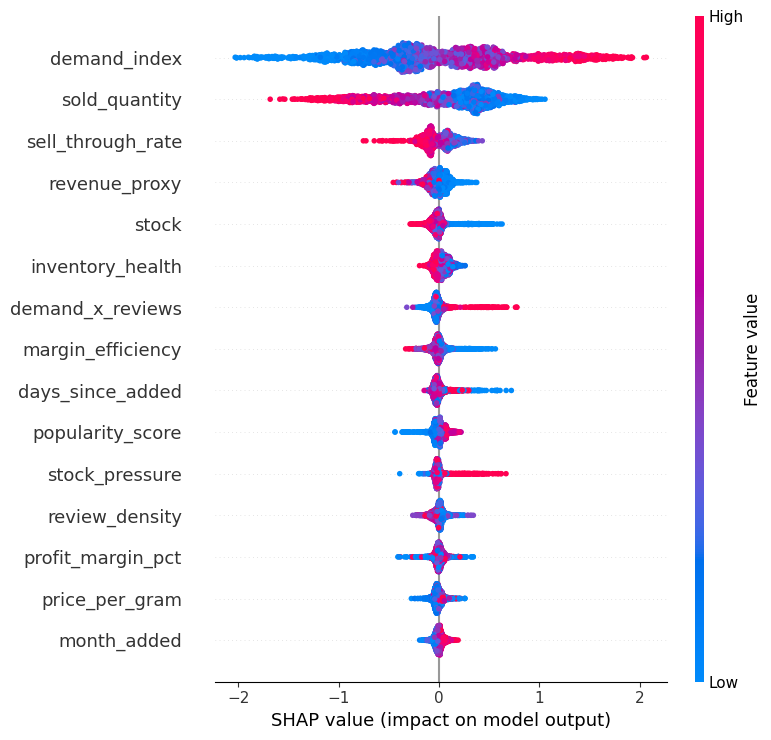

In [23]:
import shap

explainer   = shap.TreeExplainer(search_grid.best_estimator_)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=FEAT_COLS, max_display=15)

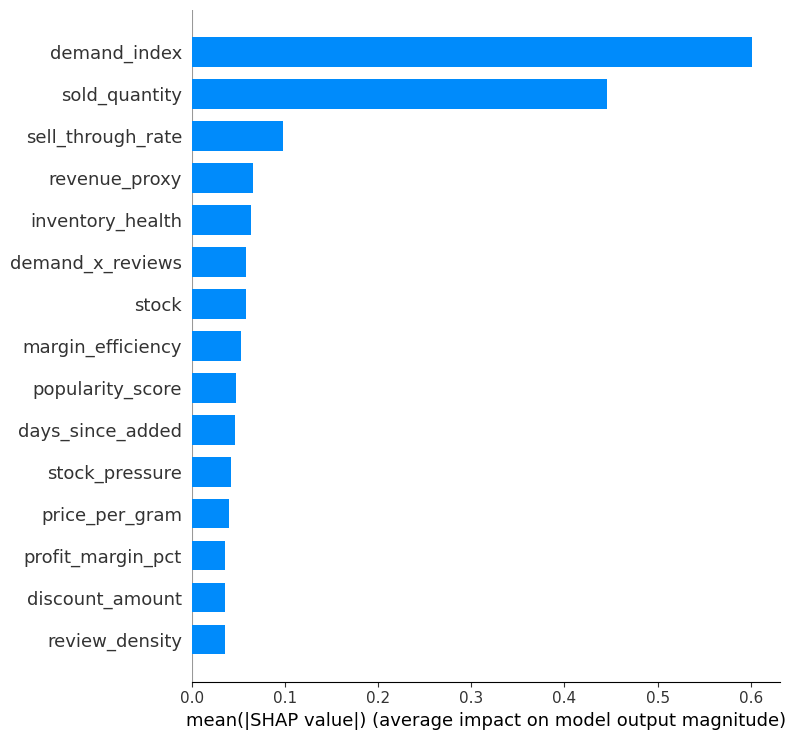

In [ ]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEAT_COLS,
                  plot_type="bar", max_display=15)

In [12]:
import mlflow, mlflow.sklearn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("blinkInsighT")

with mlflow.start_run(run_name="lgbm_post_launch") as run:
    mlflow.sklearn.log_model(
        best_lgbm,
        name="lgbm_post_launch",
        registered_model_name="lgbm_post_launch",
    )
    mlflow.log_params(best_lgbm.get_params())

    Y_pred = best_lgbm.predict(X_test_scaled)
    mlflow.log_metrics({
        "accuracy":  round(accuracy_score(Y_test, Y_pred), 4),
        "precision": round(precision_score(Y_test, Y_pred), 4),
        "recall":    round(recall_score(Y_test, Y_pred), 4),
        "f1":        round(f1_score(Y_test, Y_pred), 4),
        "macro_f1":  round(f1_score(Y_test, Y_pred, average="macro"), 4),
    })

    print("Run ID:", run.info.run_id)
    print("Post-launch model saved!")


/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/06/10 20:02:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: c6becd83e41e45c3a72874cf324c3159
Post-launch model saved!


Successfully registered model 'lgbm_post_launch'.
Created version '1' of model 'lgbm_post_launch'.
/home/khushijha/Workspace/blinkGPT/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
